# Coming from vanilla JuPedSim? Same study, two ways

If you already write [JuPedSim](https://www.jupedsim.org/) simulations by
hand — shapely geometry, `jps.Simulation`, journeys, the iteration loop —
this notebook is for you. It runs the **same bottleneck study twice**:
once with vanilla `jupedsim`, once with `jupedsim-scenarios`, so you can
judge the difference on identical physics.

`jupedsim-scenarios` is not a replacement for JuPedSim — it *wraps* it.
The solver, the models, and the results are the same. What changes is how
much code sits between you and your research question:

| Task | vanilla `jupedsim` | `jupedsim-scenarios` |
|---|---|---|
| Build + run one bottleneck | ~45 lines (Part 1) | ~10 lines (Part 2) |
| Trajectory output | manage `SqliteTrajectoryWriter` yourself | temp SQLite + `trajectory_dataframe()` |
| Parameters × seeds study | hand-rolled loops + bookkeeping ([`bottleneck_sweep.py`](https://github.com/PedestrianDynamics/jupedsim-scenarios/blob/main/examples/bottleneck_sweep.py), ~190 lines) | one `run_sweep(...)` call (Part 3) |
| Scenarios from the [web editor](https://github.com/PedestrianDynamics/jupedsim-web-community) | parse the JSON yourself | `load_scenario("export.zip")` |

```bash
pip install jupedsim-scenarios
```

In [1]:
import logging
from datetime import datetime

logging.getLogger("jupedsim_scenarios").setLevel(logging.WARNING)
print(f"Executed on {datetime.now().strftime('%d.%m.%Y, %H:%M')}")

Executed on 20.07.2026, 23:27


## Part 1 — the bottleneck in vanilla JuPedSim

A square room, a 1.2 m door through a dividing wall, a downstream room
with an exit. 50 agents evacuate under the Collision-Free Speed Model.
This is the canonical vanilla recipe: build the walkable polygon, place
agents, wire stage → journey → agents, then drive the loop yourself.

In [2]:
import tempfile
from pathlib import Path

import jupedsim as jps
from shapely.geometry import Polygon
from shapely.ops import unary_union

# --- geometry: room + door channel + downstream room ---
DOOR_WIDTH = 1.2
room = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])
half = DOOR_WIDTH / 2
door_channel = Polygon([(10, 5 - half), (10.4, 5 - half), (10.4, 5 + half), (10, 5 + half)])
downstream = Polygon([(10.4, 0), (16, 0), (16, 10), (10.4, 10)])
walkable = unary_union([room, door_channel, downstream])
exit_polygon = Polygon([(15.5, 4), (16, 4), (16, 6), (15.5, 6)])
spawn_polygon = Polygon([(0.5, 0.5), (9, 0.5), (9, 9.5), (0.5, 9.5)])

# --- agent placement: clearances are on you ---
NUM_AGENTS, RADIUS = 50, 0.2
positions = jps.distribute_by_number(
    polygon=spawn_polygon,
    number_of_agents=NUM_AGENTS,
    distance_to_agents=2 * RADIUS + 0.1,
    distance_to_polygon=RADIUS + 0.05,
    seed=42,
)

# --- simulation + trajectory writer lifecycle: also on you ---
DT = 0.05
trajectory_file = Path(tempfile.mkdtemp()) / "vanilla_bottleneck.sqlite"
simulation = jps.Simulation(
    model=jps.CollisionFreeSpeedModel(),
    geometry=walkable,
    dt=DT,
    trajectory_writer=jps.SqliteTrajectoryWriter(
        output_file=trajectory_file, every_nth_frame=4
    ),
)

# --- stage -> journey -> per-agent parameter plumbing ---
exit_id = simulation.add_exit_stage(exit_polygon)
journey_id = simulation.add_journey(jps.JourneyDescription([exit_id]))
for position in positions:
    simulation.add_agent(
        jps.CollisionFreeSpeedModelAgentParameters(
            position=position,
            journey_id=journey_id,
            stage_id=exit_id,
            desired_speed=1.2,
            radius=RADIUS,
        )
    )

# --- the loop: stop condition and iteration budget are yours to get right ---
MAX_ITERATIONS = 6000
while simulation.agent_count() > 0 and simulation.iteration_count() < MAX_ITERATIONS:
    simulation.iterate()

vanilla_evac_time = simulation.elapsed_time()
print(f"evacuation time: {vanilla_evac_time:.1f} s "
      f"({simulation.iteration_count()} iterations)")

evacuation time: 45.2 s (905 iterations)


It works — but count what you had to own that is *not* your research
question: placement clearances, the writer's file and frame stride, the
stage/journey wiring, per-agent parameter objects, the stop condition,
and an iteration budget so a jammed door can't hang the notebook.

## Part 2 — the same study with `jupedsim-scenarios`

Same walkable polygon, same exit, same spawn area, same model — the
shapely objects from Part 1 are passed straight in. Everything from the
"on you" list above is handled by `run_scenario`.

In [3]:
from jupedsim_scenarios import Scenario, run_scenario

scenario = Scenario(
    raw={},
    walkable_area_wkt=walkable.wkt,
    model_type="CollisionFreeSpeedModel",
    seed=42,
    sim_params={"max_simulation_time": 300},
)
scenario.add_distribution(spawn_polygon, number=NUM_AGENTS, desired_speed=1.2, radius=RADIUS)
scenario.add_exit(exit_polygon)

result = run_scenario(scenario, seed=42)
print(f"evacuation time: {result.evacuation_time:.1f} s  (vanilla: {vanilla_evac_time:.1f} s)")

evacuation time: 43.0 s  (vanilla: 45.2 s)


The two times agree closely but not exactly: both runs use the same
solver, the same model defaults, and even the same seed value — but
the two code paths implement agent placement independently, so the
initial positions differ. Think of the runs as two independent draws
of the same experiment, not bit-identical replays.

What the ~10 lines bought beyond brevity:

- `result` carries the run: `result.evacuation_time`,
  `result.trajectory_dataframe()` (ready for
  [pedpy](https://pedpy.readthedocs.io/) analysis — see the
  [visualisation how-to](02_visualisation.ipynb)), `result.cleanup()`.
- The scenario is an object you can mutate (`set_agent_count`,
  `set_agent_params`, `add_zone`, …) and persist with `save_scenario`.
- The same `run_scenario` accepts scenarios drawn in the
  [web editor](https://github.com/PedestrianDynamics/jupedsim-web-community):
  `load_scenario("export.zip")` — no JSON parsing.

In [4]:
df = result.trajectory_dataframe()
print(f"trajectory: {len(df)} rows, columns: {list(df.columns)}")
result.cleanup();

trajectory: 12425 rows, columns: ['frame', 'id', 'x', 'y', 'ori_x', 'ori_y']


## Part 3 — the payoff: a parameters × seeds study in one call

In vanilla JuPedSim a sweep means loops, per-run output files, a results
table, and censoring bookkeeping —
[`bottleneck_sweep.py`](https://github.com/PedestrianDynamics/jupedsim-scenarios/blob/main/examples/bottleneck_sweep.py)
does it properly in ~190 lines. With `run_sweep` you declare *what*
varies (`axes`) and *how* to inject it (`apply`); copies, seeds,
parallel workers, and the results table are handled for you.

Here: does desired speed move the evacuation time? 3 speeds × 3 seeds =
9 runs (about a minute).

In [5]:
from jupedsim_scenarios import run_sweep

sweep = run_sweep(
    scenario,
    axes={"desired_speed": [0.8, 1.2, 1.5]},
    apply={"desired_speed": lambda s, v: s.set_agent_params(0, desired_speed=v)},
    seeds=range(1, 4),
    workers=2,
)
df = sweep.to_dataframe()
df[["desired_speed", "seed", "evacuation_time"]]

,desired_speed,seed,evacuation_time
0,0.8,1,53.30
1,0.8,2,50.68
2,0.8,3,53.72
3,1.2,1,45.82
4,1.2,2,46.60
5,1.2,3,41.04
6,1.5,1,40.43
7,1.5,2,42.95
8,1.5,3,41.60


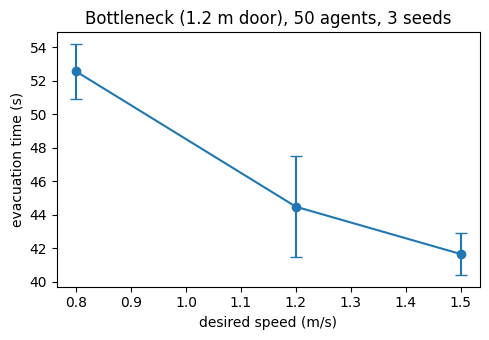

In [6]:
import matplotlib.pyplot as plt

stats = df.groupby("desired_speed")["evacuation_time"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(stats.index, stats["mean"], yerr=stats["std"],
            marker="o", capsize=4)
ax.set_xlabel("desired speed (m/s)")
ax.set_ylabel("evacuation time (s)")
ax.set_title(f"Bottleneck ({DOOR_WIDTH} m door), {NUM_AGENTS} agents, 3 seeds")
fig.tight_layout()
plt.show()

sweep.cleanup();

To sweep something that changes the *geometry* itself — like the door
width — build each scenario fresh with `run_sweep_from_factory`:

```python
from jupedsim_scenarios import run_sweep_from_factory

def make(params):
    scenario = Scenario(
        raw={},
        walkable_area_wkt=build_geometry(params["door_width"]).wkt,  # your function
        model_type="CollisionFreeSpeedModel",
        seed=42,
        sim_params={"max_simulation_time": 300},
    )
    scenario.add_distribution(spawn_polygon, number=NUM_AGENTS, desired_speed=1.2)
    scenario.add_exit(exit_polygon)
    return scenario

sweep = run_sweep_from_factory(
    make,
    trials=[{"door_width": w} for w in (0.8, 1.2, 1.6, 2.4)],
    seeds=range(1, 4),
    workers=4,
)
```

The [bottleneck tutorial](../bottleneck_tutorial.ipynb) runs exactly
this kind of model × door-width grid and reproduces the known flow
physics.

## When vanilla JuPedSim is still the right tool

Direct use of `jupedsim` remains the way to go when you need what the
wrapper doesn't expose: per-iteration control of the loop (rerouting
agents mid-run, custom waiting logic, direct steering), custom
trajectory serializers, or model features outside the scenario schema.
For everything on the run–sweep–analyze path, start here and keep your
code at the level of your research question.

**Next steps:** [sweep basics](05_sweep_basics.ipynb) ·
[build a scenario from scratch](09_build_from_scratch.ipynb) ·
[visualise trajectories](02_visualisation.ipynb)